# DeepSeek Coder 6.7b Instruct - HumanEval Benchmark Pipeline with Contextual Bandit

This notebook implements a pipeline to benchmark the `deepseek-ai/deepseek-coder-6.7b-instruct` model on the HumanEval dataset using various prompting strategies.
We use contextual bandit to adaptively select from: zero_shot, few_shot, cot, hint.
 **Bandit-Optimized** (adaptive from all strategies)

Finally, we calculate the Pass@1 score using a custom serial evaluator (Windows-compatible) and compare.

In [1]:
import torch
import numpy as np
import ast  # For compile check
from transformers import AutoTokenizer, AutoModelForCausalLM
from human_eval.data import write_jsonl, read_problems
from tqdm import tqdm
import json
import os
import sys
import gc

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Model Loading
We load the model with 4-bit quantization to save memory. If you have enough VRAM (24GB+), you can remove `load_in_4bit=True`.

In [2]:
model_name = "deepseek-ai/deepseek-coder-1.3b-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)
model.eval()
print("Model loaded successfully!")

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Model loaded successfully!


## 2. Prompting Strategies (for Baseline and Bandit Arms)
Define functions to construct prompts. For bandit, arms correspond to strategies: 0=zero_shot, 1=few_shot, 2=cot, 3=hint.

In [3]:
def get_enhanced_prompt(arm_id, problem):
    base_instruction = "You are an expert Python programmer. Complete the function by writing ONLY the code that goes inside the function body. Do NOT repeat the function signature, do NOT add comments, do NOT write tests.\n\n"
    
    if arm_id == 0:  # zero_shot
        prompt_content = base_instruction + f"Complete this function:\n\n{problem['prompt']}"
    
    elif arm_id == 1:  # few_shot
        examples = '''
        Example 1:
        Problem: 
        def add(a, b):
            """Returns the sum of a and b"""
            
        Solution:
            return a + b

        Example 2:
        Problem:
        def reverse_string(s):
            """Reverses the input string"""
            
        Solution:
            return s[::-1]

        Example 3:
        Problem:
        def find_max(lst):
            """Finds the maximum value in a list"""
            
        Solution:
            return max(lst)
        '''
        prompt_content = base_instruction + f"Here are examples of completed functions:\n{examples}\n\nNow complete this function:\n\n{problem['prompt']}"
    
    elif arm_id == 2:  # cot
        prompt_content = f"Think step by step about how to solve this problem, then write the code. First, reason about the approach, then provide the code.\n\nProblem:\n{problem['prompt']}\n\nReasoning: Let me think about this step by step. "
    
    elif arm_id == 3:  # hint
        # Problem-specific hints based on content
        prompt_text = problem['prompt'].lower()
        if any(word in prompt_text for word in ['sort', 'sorted', 'order']):
            hint = "Hint: Consider efficient sorting algorithms and time complexity."
        elif any(word in prompt_text for word in ['tree', 'node', 'binary']):
            hint = "Hint: Consider recursion or iterative traversal for tree structures."
        elif any(word in prompt_text for word in ['string', 'text', 'character']):
            hint = "Hint: Consider string manipulation methods and edge cases like empty strings."
        else:
            hint = "Hint: Consider edge cases and efficient data structures."
        
        prompt_content = base_instruction + f"{hint}\n\nComplete this function:\n\n{problem['prompt']}"
    
    messages = [{'role': 'user', 'content': prompt_content}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

## 3. Generation Pipeline (Modified for Bandit)
Iterate through HumanEval problems and generate solutions. For baseline, use fixed arm=0 (zero_shot). For bandit, select dynamically from all arms.

In [4]:
def generate_solutions(problems, bandit=None, fixed_arm=None, num_samples=1):
    torch.cuda.empty_cache()
    gc.collect()
    
    samples = []
    print("Starting generation...")
    
    for task_id, problem in tqdm(problems.items(), desc="Generating"):
        # FIX: Extract features dulu sebelum select_arm
        context_features = extract_features(problem)
        
        if bandit:
            arm = bandit.select_arm(np.array(context_features))
        else:
            arm = fixed_arm
        
        # FIX: Use enhanced prompt
        prompt = get_enhanced_prompt(arm, problem)
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(model.device)
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=512,
                do_sample=False,
                temperature=0.1,  # FIX: Add slight temperature untuk variability
                pad_token_id=tokenizer.eos_token_id,
            )
        
        generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True).strip()
        
        # FIX: Better code extraction
        if "```python" in generated:
            code = generated.split("```python")[1].split("```")[0].strip()
        elif "```" in generated:
            code = generated.split("```")[1].split("```")[0].strip()
        else:
            # Remove reasoning text untuk CoT
            if "Reasoning:" in generated:
                code_part = generated.split("Reasoning:")[-1]
                # Extract hanya baris kode yang masuk akal
                lines = [line for line in code_part.split('\n') if line.strip() and not line.strip().startswith(('#', '"'))]
                code = '\n'.join(lines[-5:])  # Ambil 5 baris terakhir
            else:
                code = generated
        
        sample = {
            "task_id": task_id,
            "completion": code,
            "arm": arm,
            "context": context_features  # FIX: Simpan features asli
        }
        samples.append(sample)
    
    return samples

## 4. Custom Evaluation (Windows Compatible) with Reward Calculation
Custom serial evaluator with timeout. Added compile check and reward calc for bandit.

In [13]:
# 4. Custom Evaluation (Windows Compatible + Live Progress + TIMEOUT + STRATEGY LOGGING)
from tqdm import tqdm
import threading
import ast

# Mapping arm_id → nama strategi (sama seperti yang Anda pakai di get_prompt)
STRATEGY_NAMES = {
    0: "zero_shot",
    1: "few_shot",
    2: "cot",
    3: "hint"
}
def run_with_timeout(code, timeout_seconds=10):
    result = {'success': False, 'error': None}
    def target():
        try:
            exec_globals = {}
            exec(code, exec_globals)
            result['success'] = True
        except Exception as e:
            result['error'] = e
    thread = threading.Thread(target=target)
    thread.daemon = True
    thread.start()
    thread.join(timeout_seconds)
    if thread.is_alive():
        return False, 'TIMEOUT'
    return result['success'], result.get('error')
def check_compile(code):
    try:
        ast.parse(code)
        return 1
    except SyntaxError:
        return 0
def evaluate_functional_correctness_custom(samples, problems, timeout=10, bandit=None):
    passed = 0
    total = len(samples)
    cumulative_reward = 0.0
    
    print(f"Evaluating {total} samples...\n")
    pbar = tqdm(samples, desc="Evaluating")
    
    for i, sample in enumerate(pbar):
        task_id = sample['task_id']
        completion = sample['completion']
        problem = problems[task_id]
        
        # FIX: Better code construction
        full_code = problem['prompt'] + completion + "\n" + problem['test']
        
        # Add check call
        if f"check({problem['entry_point']})" not in full_code:
            full_code += f"\n\ncheck({problem['entry_point']})"
        
        compile_success = check_compile(full_code)
        pass_success, error = run_with_timeout(full_code, timeout)
        
        # FIX: Better reward function
        if pass_success:
            reward = 1.0
        elif compile_success:
            reward = 0.3  # Partial reward untuk compilation only
        else:
            reward = 0.0
            
        cumulative_reward += reward
        
        sample['passed'] = pass_success
        sample['compile_ok'] = bool(compile_success)
        sample['reward'] = reward
        sample['strategy'] = STRATEGY_NAMES.get(sample['arm'], f"arm_{sample['arm']}")
        
        # FIX: Bandit update dengan context yang benar
        if bandit and 'arm' in sample and 'context' in sample:
            try:
                context_array = np.array(sample['context']).reshape(-1, 1)
                bandit.update(sample['arm'], context_array, reward)
                print(f"  Updated arm {sample['arm']} with reward {reward:.2f}")
            except Exception as e:
                print(f"  Update failed: {e}")
        
        if pass_success:
            passed += 1
            
        current_score = (passed / (i + 1)) * 100
        pbar.set_postfix({
            "Pass@1": f"{current_score:5.1f}%",
            "Reward": f"{reward:.2f}",
            "Arm": sample['arm']
        })
    
    final_score = (passed / total) * 100
    avg_reward = cumulative_reward / total
    print(f"\nFINAL → Pass@1: {final_score:.1f}% | Avg Reward: {avg_reward:.3f}\n")
    
    return {"pass@1": final_score, "avg_reward": avg_reward}

## 5. Context Extraction for Bandit
Extract simple features from problem as context vector.

In [14]:
DIM_CONTEXT = 19 
def extract_features(problem):
    prompt = problem['prompt']
    
    # FIX: Handle docstring extraction lebih robust
    if '"""' in prompt:
        parts = prompt.split('"""')
        docstring = parts[1].lower() if len(parts) > 1 else prompt.lower()
    else:
        docstring = prompt.lower()
    
    input_ids = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=2048)['input_ids'][0]
    token_len = len(input_ids)
    
    words = docstring.split()
    doc_len = len(words)
    
    # FIX: Features yang lebih meaningful
    features = [
        min(token_len / 500.0, 1.0),      # Normalized token length
        min(doc_len / 100.0, 1.0),        # Normalized doc length  
        len(set(words)) / max(doc_len, 1), # Vocabulary richness ratio
        docstring.count('\n') / 10.0,     # Line count
        float('return' in docstring),     # Boolean as float
        float('for ' in docstring or 'while ' in docstring),
        float('if ' in docstring),
        float('def ' in docstring),
        float('list' in docstring or 'array' in docstring),
        float('string' in docstring or 'text' in docstring),
        float('sort' in docstring or 'sorted' in docstring),
        float('graph' in docstring or 'node' in docstring or 'edge' in docstring),
        float('tree' in docstring or 'root' in docstring),
        float('dp' in docstring or 'memo' in docstring or 'cache' in docstring),
        float('recursion' in docstring or 'recursive' in docstring),
        float('bit' in docstring or '&' in docstring or '|' in docstring),
        float('greedy' in docstring),
        float('math' in docstring or 'formula' in docstring),
        float('geometry' in docstring or 'point' in docstring)
    ]
    
    while len(features) < DIM_CONTEXT:
        features.append(0.0)
    
    return features[:DIM_CONTEXT]  # Truncate if longer

## 6. Contextual Bandit Implementation (LinUCB)
Simple LinUCB for contextual bandit.

In [15]:
import threading 

class OnlineLinUCB:
    def __init__(self, num_arms=4, dim_context=19, alpha=0.3, force_explore=40):
        self.num_arms = num_arms
        self.dim_context = dim_context
        self.alpha = alpha
        self.force_explore = force_explore
        self.t = 0
        
        self.A = [np.eye(dim_context) + 0.01 * np.eye(dim_context) for _ in range(num_arms)]
        self.b = [np.zeros((dim_context, 1)) for _ in range(num_arms)]
        self.theta = [np.zeros((dim_context, 1)) for _ in range(num_arms)]
        
        self.arm_counts = [0] * num_arms
        self.arm_rewards = [[] for _ in range(num_arms)]
        self.cumulative_reward = 0.0
    
    def select_arm(self, context):
        self.t += 1
        
        # Phase 1: Forced exploration
        if self.t <= self.force_explore:
            arm = (self.t - 1) % self.num_arms
            self.arm_counts[arm] += 1
            print(f"[EXPLORE] t={self.t:3d} → arm {arm}")
            return arm
        
        context = context.reshape(-1, 1)
        ucb_values = []
        
        for a in range(self.num_arms):
            try:
                A_inv = np.linalg.inv(self.A[a])
                theta = self.theta[a]
                
                mean = float((theta.T @ context)[0, 0])
                uncertainty = float((self.alpha * np.sqrt(context.T @ A_inv @ context))[0, 0])
                
                # Gunakan historical performance sebagai prior
                historical_perf = np.mean(self.arm_rewards[a]) if self.arm_rewards[a] else 0.0
                
                ucb = mean + uncertainty + historical_perf * 0.5
                ucb_values.append(ucb)
                
            except np.linalg.LinAlgError:
                ucb_values.append(float('-inf'))
        
        chosen = np.argmax(ucb_values)
        self.arm_counts[chosen] += 1
        
        # Debug info dengan REAL rewards
        avg_rewards = [f"{np.mean(rewards):.3f}" if rewards else "0.000" for rewards in self.arm_rewards]
        print(f"[UCB] t={self.t:3d} → arm {chosen}")
        print(f"      Arm counts: {self.arm_counts}")
        print(f"      Real avg rewards: {avg_rewards}")
        
        return chosen
    
    def update(self, arm, context, reward):
        context = context.reshape(-1, 1)
        
        # Update model
        self.A[arm] += context @ context.T
        self.b[arm] += reward * context
        self.arm_rewards[arm].append(reward)
        self.cumulative_reward += reward
        
        try:
            self.theta[arm] = np.linalg.inv(self.A[arm]) @ self.b[arm]
        except np.linalg.LinAlgError:
            self.theta[arm] = np.linalg.pinv(self.A[arm]) @ self.b[arm]
        
        # Immediate feedback
        print(f"  → Updated arm {arm} with reward {reward:.2f}")
        print(f"  → Cumulative reward: {self.cumulative_reward:.2f}")
        
def run_online_bandit_experiment(problems, bandit, timeout=10):
    """
    Online contextual bandit: Generate & evaluate per problem
    """
    torch.cuda.empty_cache()
    gc.collect()
    
    samples = []
    print("Starting ONLINE bandit experiment...")
    
    # Process problems sequentially dengan online learning
    for task_id, problem in tqdm(problems.items(), desc="Online Bandit"):
        # 1. Extract context features
        context_features = extract_features(problem)
        
        # 2. Bandit selects arm based on current knowledge
        arm = bandit.select_arm(np.array(context_features))
        
        # 3. Generate solution
        prompt = get_enhanced_prompt(arm, problem)
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(model.device)
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=512,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        
        generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True).strip()
        
        # Extract code
        if "```python" in generated:
            code = generated.split("```python")[1].split("```")[0].strip()
        elif "```" in generated:
            code = generated.split("```")[1].split("```")[0].strip()
        else:
            code = generated
        
        # 4. IMMEDIATE EVALUATION
        full_code = problem['prompt'] + code + "\n" + problem['test']
        if f"check({problem['entry_point']})" not in full_code:
            full_code += f"\n\ncheck({problem['entry_point']})"
        
        compile_success = check_compile(full_code)
        pass_success, error = run_with_timeout(full_code, timeout)
        
        # 5. Calculate reward
        if pass_success:
            reward = 1.0
        elif compile_success:
            reward = 0.3
        else:
            reward = 0.0
        
        # 6. IMMEDIATE BANDIT UPDATE
        bandit.update(arm, np.array(context_features), reward)
        
        # 7. Store sample
        sample = {
            "task_id": task_id,
            "completion": code,
            "arm": arm,
            "context": context_features,
            "passed": pass_success,
            "reward": reward,
            "strategy": STRATEGY_NAMES.get(arm, f"arm_{arm}")
        }
        samples.append(sample)
        
        # Progress tracking
        current_pass = sum(1 for s in samples if s['passed'])
        current_avg_reward = sum(s['reward'] for s in samples) / len(samples)
        
        print(f"  {task_id} → Arm {arm} → Reward: {reward:.2f} → Pass@1: {current_pass}/{len(samples)} ({current_pass/len(samples)*100:.1f}%)")
    
    return samples

## 7. Execution & Benchmark (Baseline vs Bandit)
Run baseline (fixed zero-shot) then bandit-optimized (from all strategies).

In [16]:
import os
import urllib.request
import torch
import gc
import random

HUMAN_EVAL_URL = "https://github.com/openai/human-eval/raw/master/data/HumanEval.jsonl.gz"
LOCAL_EVAL_FILE = "HumanEval.jsonl.gz"

if not os.path.exists(LOCAL_EVAL_FILE):
    print("Downloading HumanEval dataset...")
    urllib.request.urlretrieve(HUMAN_EVAL_URL, LOCAL_EVAL_FILE)
    print("Downloaded.")
results_summary = {}
problems = read_problems(LOCAL_EVAL_FILE)
problems = dict(list(problems.items()))  
problem_items = list(problems.items())
random.seed(42)                  
random.shuffle(problem_items)
problems = dict(problem_items)

# FIX: Ada typo di sini - tambahkan class name
bandit = OnlineLinUCB(  # ← TAMBAHKAN OnlineLinUCB
    num_arms=4,
    dim_context=19,
    alpha=0.3,        # Gunakan 0.3, bukan 0.1
    force_explore=40   # 40 samples exploration
)

print("Starting ONLINE contextual bandit experiment...")
torch.cuda.empty_cache()
gc.collect()

# PAKAI ONLINE LEARNING (yang sudah include evaluation)
samples_bandit = run_online_bandit_experiment(problems, bandit, timeout=10)

# Final results calculation
passed = sum(sample['passed'] for sample in samples_bandit)
total = len(samples_bandit)
final_pass_at_1 = (passed / total) * 100
avg_reward = sum(sample['reward'] for sample in samples_bandit) / total

results_bandit = {
    "pass@1": final_pass_at_1,
    "avg_reward": avg_reward,
    "total_samples": total,
    "passed_samples": passed,
    "arm_distribution": dict(enumerate(bandit.arm_counts)),
    "arm_performance": {
        i: np.mean(bandit.arm_rewards[i]) if bandit.arm_rewards[i] else 0.0 
        for i in range(4)
    }
}

results_summary['online_bandit'] = results_bandit
print(f"Online Bandit Results: {results_bandit}")

Starting ONLINE contextual bandit experiment...
Starting ONLINE bandit experiment...


Online Bandit:   0%|          | 0/164 [00:00<?, ?it/s]

[EXPLORE] t=  1 → arm 0


Online Bandit:   1%|          | 1/164 [00:04<11:34,  4.26s/it]

False
True
True
False
  → Updated arm 0 with reward 1.00
  → Cumulative reward: 1.00
  HumanEval/61 → Arm 0 → Reward: 1.00 → Pass@1: 1/1 (100.0%)
[EXPLORE] t=  2 → arm 1


...

('Saturn', 'Uranus')
('Venus',)
('Venus', 'Earth', 'Mars', 'Jupiter', 'Saturn')
  → Updated arm 0 with reward 1.00
  → Cumulative reward: 85.60
  HumanEval/148 → Arm 0 → Reward: 1.00 → Pass@1: 67/132 (50.8%)
[UCB] t=133 → arm 0
      Arm counts: [40, 51, 24, 18]
      Real avg rewards: ['0.723', '0.665', '0.550', '0.572']


Online Bandit:  81%|████████  | 133/164 [11:48<04:52,  9.43s/it]

  → Updated arm 0 with reward 0.30
  → Cumulative reward: 85.90
  HumanEval/39 → Arm 0 → Reward: 0.30 → Pass@1: 67/133 (50.4%)
[UCB] t=134 → arm 0
      Arm counts: [41, 51, 24, 18]
      Real avg rewards: ['0.713', '0.665', '0.550', '0.572']


Online Bandit:  81%|████████  | 133/164 [23:50<05:33, 10.75s/it]


KeyboardInterrupt: 

## 8. Final Results Comparison

                  pass@1 avg_reward total_samples passed_samples  \
online_bandit  68.292683   0.778049           164            112   

                           arm_distribution  \
online_bandit  {0: 12, 1: 26, 2: 96, 3: 30}   

                                                 arm_performance  
online_bandit  {0: 0.5333333333333333, 1: 0.7038461538461539,...  


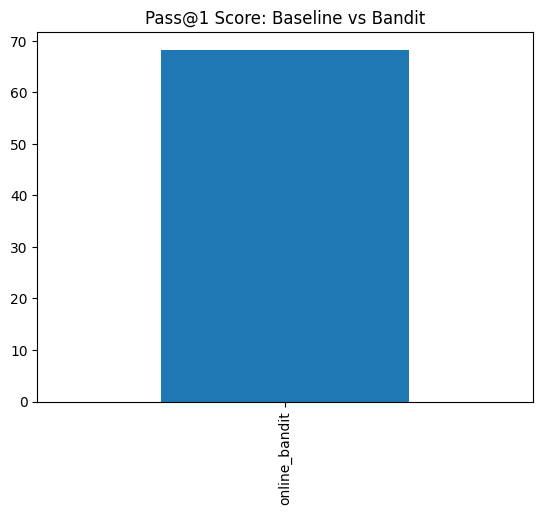

In [ ]:
import pandas as pd

df = pd.DataFrame(results_summary).T
print(df)

# Optional: Plotting
try:
    df['pass@1'].plot(kind='bar', title='Pass@1 Score: Baseline vs Bandit')
except ImportError:
    pass

In [ ]:
# === ANALISIS STRATEGI YANG DIPILIH BANDIT ===
print("="*70)
print("ANALISIS PEMILIHAN STRATEGI OLEH CONTEXTUAL BANDIT")
print("="*70)

from collections import Counter

strategies_used = [s['strategy'] for s in samples_bandit if 'strategy' in s]
counts = Counter(strategies_used)
total = len(strategies_used)

print(f"\nDistribusi Pemilihan Strategi (total {total} soal):")
print("-" * 55)
for strategy, cnt in counts.most_common():
    perc = cnt / total * 100
    passed_cnt = sum(1 for s in samples_bandit if s.get('strategy') == strategy and s.get('passed'))
    pass_rate = passed_cnt / cnt * 100 if cnt > 0 else 0
    print(f"{strategy:10} → {cnt:3d} kali ({perc:5.1f}%) → Pass@1: {pass_rate:5.1f}%")

# Strategi terbaik
if counts:
    best = max(counts.keys(), key=lambda x: sum(1 for s in samples_bandit if s.get('strategy')==x and s.get('passed',False)) / counts[x])
    best_rate = sum(1 for s in samples_bandit if s.get('strategy')==best and s.get('passed',False)) / counts[best] * 100
    print(f"\nStrategi TERBAIK yang dipelajari bandit → {best} ({best_rate:.1f}%)")
    print(f"Overall Pass@1 bandit                  → {results_bandit['pass@1']:.1f}%")
    print(f"Potensi maksimal (oracle)              → {best_rate:.1f}%")
print("="*70)

ANALISIS PEMILIHAN STRATEGI OLEH CONTEXTUAL BANDIT

Distribusi Pemilihan Strategi (total 164 soal):
-------------------------------------------------------
cot        →  96 kali ( 58.5%) → Pass@1:  77.1%
hint       →  30 kali ( 18.3%) → Pass@1:  63.3%
few_shot   →  26 kali ( 15.9%) → Pass@1:  57.7%
zero_shot  →  12 kali (  7.3%) → Pass@1:  33.3%

Strategi TERBAIK yang dipelajari bandit → cot (77.1%)
Overall Pass@1 bandit                  → 68.3%
Potensi maksimal (oracle)              → 77.1%
